# Mean Reversion Backtest (Using Rolling PCA)

In this notebook, we backtest a cross-sectional mean reversion strategy using 4-hour crypto data from 2022 to 2024, across a universe of 70 crypto assets. We use rolling PCA to remove the common market factor and isolate the idiosyncratic component (the residual). As with the OLS case, the strategy assumes this idiosyncratic component is mean reverting over short horizons, going long assets  whose idiosyncratic residual is negative and short those where it is positive, anticipating reversion toward zero.

We conduct a parameter sweep over the following: number of components (1, 2 or 3), rolling window size, rho (the partial adjustment parameter that blends current weights with the previous period's weights to reduce turnover), alpha (the EWM smoothing parameter applied to residuals before signal construction), and the rank threshold (which controls the fraction of assets assigned non-zero weights). The ranges for these parameters were selected from a previous grid search, where we varied each parameter across a realistic range while holding the other values constant. 
The optimal configuration is selected by maximising the net Sharpe ratio on the training period and evaluated out of sample.

Overall, using only the first principal component (n_components=1) as the market common factor, a rolling window of 30 days, rho of 0.95 (5% update per bar), alpha (for EWM) of 0.5, and a rank threshold of 0.05, the strategy achieves a gross Sharpe ratio of 2.30, net Sharpe ratio of 1.19, annualised alpha of 29% and an alpha t-statistic of 3.9 against BTC as benchmark. The positive net Sharpe after 20bps transaction costs suggests the edge survives realistic execution costs. The alpha t-statistic of 3.9 against BTC provides strong evidence the strategy captures genuine idiosyncratic predictability rather than proxying broad market exposure.

In [1]:
cd -q ../../

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest_opt, run_backtest
from src.backtest.helpers import sharpe
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

### Data

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)

In [4]:
px = px.loc[:"20241231"]

## Grid Hyperparameter Optimisation

In [5]:
# Grid sweep mode
param_grid = {
    "n_comp":      [1, 2, 3],
    "window_size": [i*30*6 for i in range(1, 4)],
    "rho":         [0.9, 0.95],
    "alpha":       [0.3, 0.5, 0.7],
    "rank_thresh": [0.05, 0.1],
}

summary = run_backtest_opt(px, freq="4h", param_grid=param_grid, method="pca")

2026-03-08 19:13:19,754 INFO: Resampled to 4h


Precomputing residuals...


Sweep: 100%|██████████| 9/9 [11:09<00:00, 74.43s/it]


In [6]:
summary.head(10)

,n_comp,window_size,rho,alpha_ewm,rank_thresh,gross_sharpe,net_sharpe,avg_turnover,avg_ann,vol_ann,alpha,beta,alpha_tstat,hit_rate,avg_holding_days
0,1,180,0.95,0.5,0.05,2.297833,1.193933,0.033487,0.293166,0.127583,0.289132,0.010968,3.929945,0.571407,4.964803
1,3,360,0.95,0.3,0.05,2.015443,1.155580,0.034466,0.323046,0.160285,0.319579,0.009428,3.455687,0.571711,4.823750
2,2,180,0.95,0.5,0.05,2.261892,1.148567,0.033562,0.286976,0.126875,0.283053,0.010670,3.868639,0.567300,4.953777
3,3,180,0.95,0.5,0.05,2.277839,1.145718,0.033606,0.284657,0.124968,0.280595,0.011045,3.893956,0.566692,4.947173
4,3,360,0.95,0.5,0.05,2.126417,1.082796,0.033452,0.274906,0.129281,0.271818,0.008397,3.644501,0.580380,4.968727
5,2,360,0.95,0.3,0.05,1.882257,1.043864,0.034341,0.309087,0.164211,0.305048,0.010985,3.220152,0.569430,4.842129
6,3,180,0.90,0.3,0.05,2.365286,1.036090,0.071831,0.538899,0.227837,0.530544,0.022723,4.039558,0.563042,2.318091
7,3,360,0.90,0.3,0.05,2.279300,1.030678,0.071292,0.526913,0.231173,0.520230,0.018174,3.901844,0.576122,2.335372
8,3,180,0.95,0.3,0.05,1.938046,1.020396,0.034704,0.308074,0.158961,0.303055,0.013649,3.306080,0.558023,4.791780
9,1,180,0.90,0.5,0.05,2.577293,1.016748,0.071138,0.496288,0.192562,0.489903,0.017363,4.412335,0.575361,2.340349


## Results of Optimal Configuration

After running our parameter sweep, we find the optimal setup to use 1 principal component, a rolling window of 180 bars (~30 days), rho of 0.95, alpha of 0.5, and a rank threshold of 0.05. Note that similar performance is found for 2/3 components, which is expected: the explained variance analysis shows PC1 alone accounts for 50-70% of cross-sectional return variance, while PC2 and PC3 each contribute less than 5%.

In [7]:
opt_setup = run_backtest(px, freq="4h", rho=0.95, rank_thresh=0.05, alpha=0.5, n_comp=1, window_size=180, method="pca")

2026-03-08 19:28:12,358 INFO: Resampled to 4h


With this parameter configuration, we achieve a gross Sharpe of 2.30 and net Sharpe of 1.19, slightly below the in-sample OLS equivalents (gross: 2.76, net: 1.40), though the remaining annualised statistics are broadly similar. The strategy generates an annualised alpha of 29% (t-stat: 3.93), near-zero beta (0.01), and a hit rate of 0.57, with annualised returns of 29% on 13% volatility, yielding a favourable return-to-risk profile.

The average holding period of 5.0 days is a deliberate consequence of the smoothing (alpha = 0.5) and partial adjustment (rho = 0.95) parameters, which slow turnover and extend holding periods in exchange for lower transaction costs. As seen previously, at 20bps per trade, acting on the raw signal at every bar would be uneconomical.

### Information Coefficient (IC) Analysis

We find similar results for our IC values as with the OLS computed residuals, where our mean-reverting signal is strongest at h=1, but decays quickly. Again, this motivated us to rebalance at every bar, and explore smoothing and slowing the signal to manage turnover.

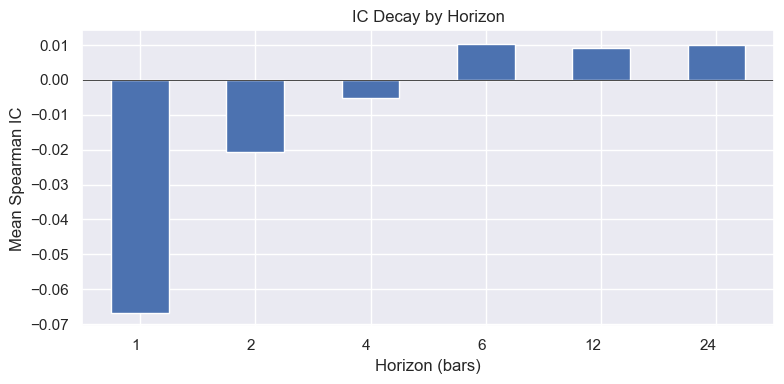

In [8]:
ic = opt_setup["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling net sharpe ratio

Below we plot the rolling 90-day net Sharpe ratio. The strategy generated consistently strong risk-adjusted returns in the early in-sample period, with rolling Sharpe ratios frequently exceeding 2 until mid-2023, and this period is the primary driver of the strong full-sample Sharpe. From mid-2023 through to mid-2024 performance deteriorates materially, with the rolling Sharpe falling below -2 at points, consistent with the drawdown analysis which identifies an extended period of negative returns over the same window. However, from mid-2024 onwards the signal quality shows strong improvement, with rolling Sharpe recovering to mostly positive levels.

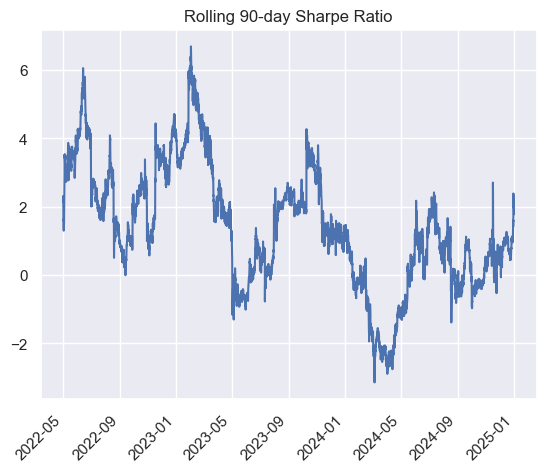

In [9]:
net_ret = opt_setup["net_ret"]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

Below we plot the gross and net cumulative returns of the PCA mean reversion strategy alongside BTC buy-and-hold as a reference. The strategy outperforms BTC through 2022 and 2023, a period during which BTC experienced severe drawdowns of approximately 65%. The strategy's market-neutral construction largely insulates it from this directional loss, generating positive returns throughout. From 2024 onwards BTC rallies strongly, and the passive buy-and-hold position overtakes the strategy in cumulative return terms, reflecting the well-known limitation of market-neutral strategies in strong bull markets: by construction they cannot participate in broad directional upside.

However, this comparison understates the strategy's value as a standalone investment. A passive BTC investor who entered at the start of 2022 would have endured two years of significant drawdowns before seeing positive cumulative returns, requiring both capital and conviction to hold through a prolonged bear market. The strategy, by contrast, generates steady positive returns throughout this period with substantially lower drawdown. The appropriate frame for evaluating a market-neutral strategy is therefore not head-to-head cumulative return against a directional asset, but rather its risk-adjusted return and its role as a diversifying allocation: on both metrics the strategy compares favourably.

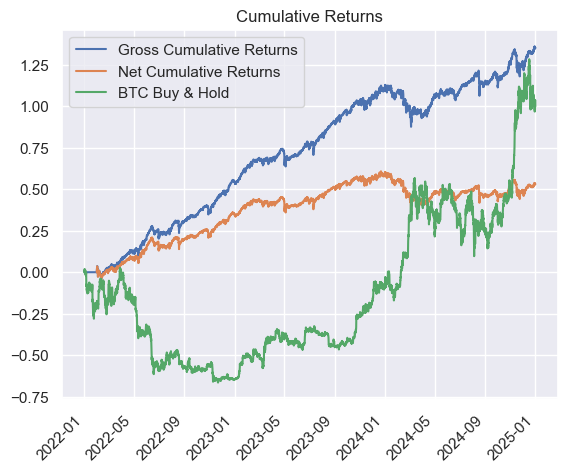

In [10]:
gross_cum = opt_setup["gross_cum"]
net_cum = opt_setup["net_cum"]

rets = rets.loc[:"20241231"]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Similar drawdown results are found to those seen for the OLS method.  The most significant drawdown begins at the start of 2024 and persists through to the end of the in-sample period without recovery, reaching a trough of -0.125.

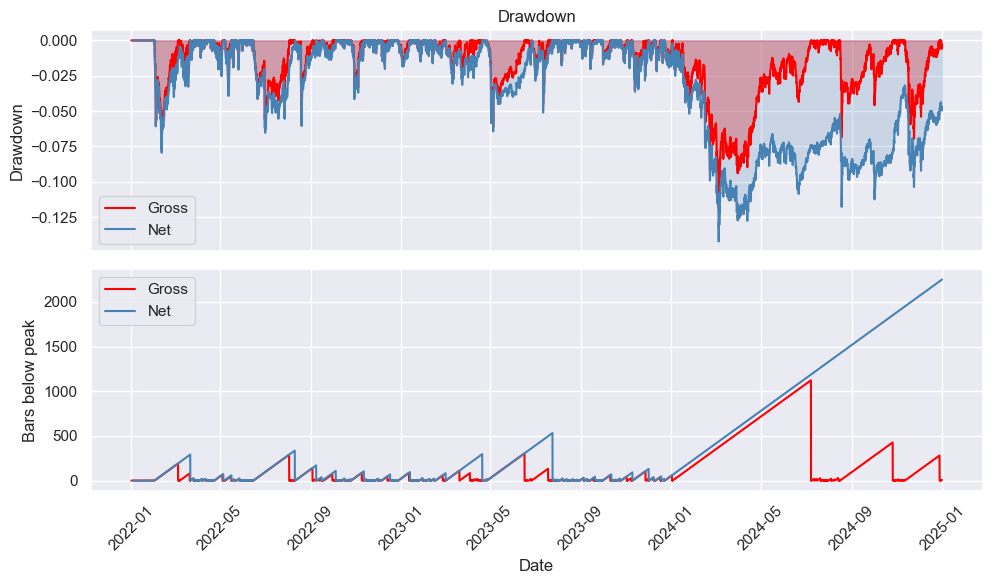

In [11]:
gross_ret = opt_setup["gross_ret"]
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

Similar to the OLS strategy, for the PCA method, grid hyperparameter optimisation has resulted in a strategy with an average turnover of 0.03, with no significant fluctuation over time.

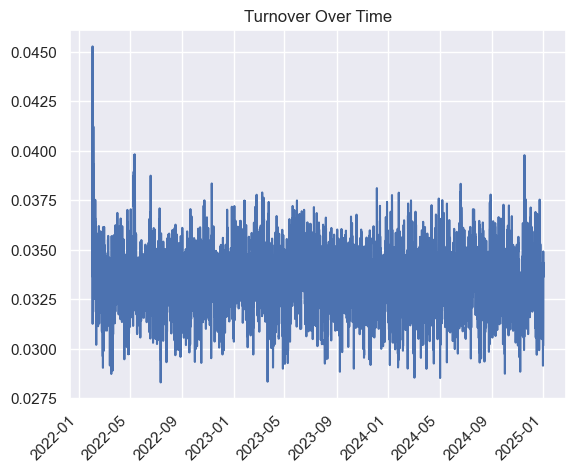

In [12]:
gross_ret = opt_setup["gross_ret"]
to = opt_setup["to"]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
plt.show()

As transaction costs increase beyond our 20bps baseline, performance degrades materially. At 40bps the strategy becomes marginally unprofitable (net Sharpe: -0.02), suggesting a relatively narrow margin of safety. While 20bps is reasonable for liquid names like BTC and ETH, smaller-cap assets in our universe may warrant a blended assumption of 25-30bps, at which point viability is less certain. Transaction cost sensitivity therefore represents a key limitation of this approach.

In [13]:
for bps in [15, 20, 30, 40]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

 15bps: net Sharpe = 1.44
 20bps: net Sharpe = 1.16
 30bps: net Sharpe = 0.59
 40bps: net Sharpe = 0.02
